# Phase 3 — Surrogate Model Training

Train ML surrogates on `data/dataset.csv` (500 SWMM runs) and compare **Random Forest vs XGBoost** on three tasks:

1. `peak_discharge_cfs` — regression
2. *floods?* (`total_flood_vol > 0`) — classification
3. `total_flood_vol` on flooded cases — regression

Design: `docs/superpowers/specs/2026-09-04-phase3-surrogate-training-design.md`.

> **Prerequisite:** run the Phase 2 notebook with `N_RUNS = 500` first so `data/dataset.csv` holds 500 rows.

## 1. Config & load data

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

def _find_root(marker="PROJECT_BRIEF.md"):
    here = Path.cwd()
    for cand in [here, *here.parents]:
        if (cand / marker).exists():
            return cand
    return here

PROJECT    = _find_root()
DATA       = PROJECT / "data" / "dataset.csv"
MODELS_DIR = PROJECT / "models"
MODELS_DIR.mkdir(exist_ok=True)
SEED = 42

df = pd.read_csv(DATA)
df = df[df["status"] == "ok"].reset_index(drop=True)

FEATURES = ["rain_mult", "imperv_mult", "surf_n", "infil_min", "pipe_n"]
X = df[FEATURES]

n_flood = int((df["total_flood_vol"] > 0).sum())
print(f"Loaded {df.shape[0]} runs x {df.shape[1]} cols | flooded: {n_flood} "
      f"({100*n_flood/len(df):.0f}%)")
if len(df) < 300:
    print("WARNING: fewer than 300 runs -- did you scale Phase 2 to N_RUNS=500 and re-run?")

Loaded 500 runs x 11 cols | flooded: 176 (35%)


## 2. Train/test split

80/20 split, fixed seed, **stratified on the flood class** so both sides contain flooded cases.

In [2]:
from sklearn.model_selection import train_test_split

y_peak  = df["peak_discharge_cfs"]
flooded = (df["total_flood_vol"] > 0).astype(int)

idx_train, idx_test = train_test_split(
    df.index, test_size=0.2, random_state=SEED, stratify=flooded
)
Xtr, Xte = X.loc[idx_train], X.loc[idx_test]

print(f"train {len(idx_train)}  test {len(idx_test)}")
print(f"flood rate -> train {flooded.loc[idx_train].mean():.2f}  "
      f"test {flooded.loc[idx_test].mean():.2f}")

train 400  test 100
flood rate -> train 0.35  test 0.35


## 3. Task 1 — peak discharge (regression)

Random Forest vs XGBoost. Report R² / RMSE / MAE on the held-out test set plus 5-fold CV R² for a stabler estimate.

In [3]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score

def reg_metrics(y_true, y_pred):
    return {
        "R2":   r2_score(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAE":  mean_absolute_error(y_true, y_pred),
    }

peak_models = {
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=SEED),
    "XGBoost": XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=4,
                            subsample=0.9, random_state=SEED),
}

rows, peak_fitted = [], {}
for name, m in peak_models.items():
    m.fit(Xtr, y_peak.loc[idx_train])
    met = reg_metrics(y_peak.loc[idx_test], m.predict(Xte))
    met["CV_R2"] = cross_val_score(m, X, y_peak, cv=5, scoring="r2").mean()
    rows.append({"task": "peak_discharge", "model": name, **met})
    peak_fitted[name] = m

peak_metrics = pd.DataFrame(rows)
best_peak = peak_metrics.sort_values("R2", ascending=False).iloc[0]["model"]
print("Best peak model:", best_peak)
peak_metrics.round(3)

Best peak model: XGBoost


,task,model,R2,RMSE,MAE,CV_R2
0,peak_discharge,RandomForest,0.980,0.638,0.431,0.975
1,peak_discharge,XGBoost,0.982,0.605,0.446,0.979


### Predicted vs SWMM + residuals (best peak model)

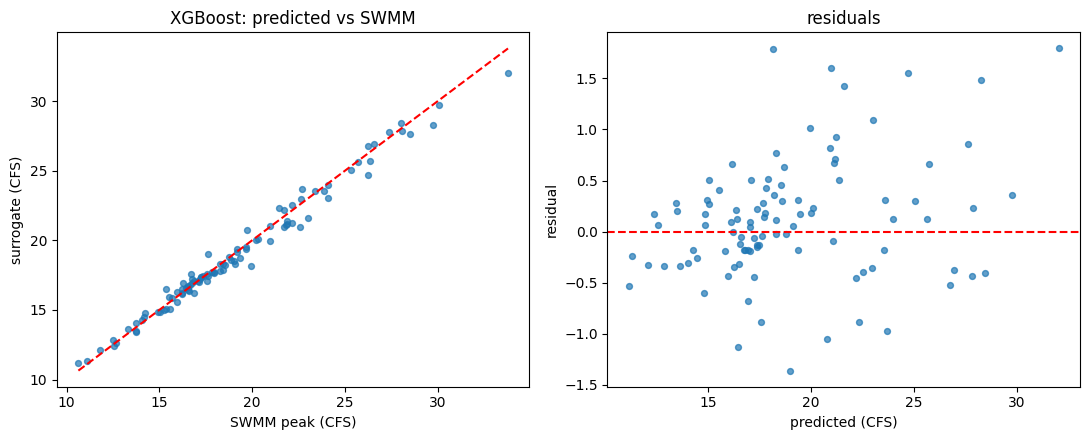

In [4]:
import matplotlib.pyplot as plt

m = peak_fitted[best_peak]
actual = y_peak.loc[idx_test]
pred   = m.predict(Xte)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].scatter(actual, pred, s=18, alpha=0.7)
lims = [actual.min(), actual.max()]
ax[0].plot(lims, lims, "r--")
ax[0].set_xlabel("SWMM peak (CFS)"); ax[0].set_ylabel("surrogate (CFS)")
ax[0].set_title(f"{best_peak}: predicted vs SWMM")
ax[1].scatter(pred, actual - pred, s=18, alpha=0.7)
ax[1].axhline(0, color="r", ls="--")
ax[1].set_xlabel("predicted (CFS)"); ax[1].set_ylabel("residual")
ax[1].set_title("residuals")
plt.tight_layout(); plt.show()

## 4. Task 2a — floods? (classification)

Stage 1 of the two-stage flood model: does this scenario flood at all?

In [5]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

ytr_c, yte_c = flooded.loc[idx_train], flooded.loc[idx_test]

clf_models = {
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=SEED),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                             subsample=0.9, random_state=SEED, eval_metric="logloss"),
}

rows, clf_fitted = [], {}
for name, m in clf_models.items():
    m.fit(Xtr, ytr_c)
    p     = m.predict(Xte)
    proba = m.predict_proba(Xte)[:, 1]
    rows.append({
        "task": "floods?", "model": name,
        "accuracy":  accuracy_score(yte_c, p),
        "precision": precision_score(yte_c, p, zero_division=0),
        "recall":    recall_score(yte_c, p, zero_division=0),
        "F1":        f1_score(yte_c, p, zero_division=0),
        "ROC_AUC":   roc_auc_score(yte_c, proba),
    })
    clf_fitted[name] = m

clf_metrics = pd.DataFrame(rows)
best_clf = clf_metrics.sort_values("F1", ascending=False).iloc[0]["model"]
print("Best classifier:", best_clf)
print("\nConfusion matrix [rows=actual, cols=pred] (0=dry, 1=flood):")
print(confusion_matrix(yte_c, clf_fitted[best_clf].predict(Xte)))
clf_metrics.round(3)

Best classifier: XGBoost

Confusion matrix [rows=actual, cols=pred] (0=dry, 1=flood):
[[65  0]
 [ 3 32]]


,task,model,accuracy,precision,recall,F1,ROC_AUC
0,floods?,RandomForest,0.96,1.0,0.886,0.939,0.996
1,floods?,XGBoost,0.97,1.0,0.914,0.955,0.995


## 5. Task 2b — flood volume (regression, flooded cases only)

Stage 2: given that a scenario floods, how much? Trained only on runs with `total_flood_vol > 0`.

In [6]:
flood_idx = df.index[df["total_flood_vol"] > 0]
ftr, fte = train_test_split(flood_idx, test_size=0.2, random_state=SEED)
yv = df["total_flood_vol"]

vol_models = {
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=SEED),
    "XGBoost": XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=4,
                            subsample=0.9, random_state=SEED),
}

rows, vol_fitted = [], {}
for name, m in vol_models.items():
    m.fit(X.loc[ftr], yv.loc[ftr])
    rows.append({"task": "flood_volume", "model": name,
                 **reg_metrics(yv.loc[fte], m.predict(X.loc[fte]))})
    vol_fitted[name] = m

vol_metrics = pd.DataFrame(rows)
best_vol = vol_metrics.sort_values("R2", ascending=False).iloc[0]["model"]
print(f"flooded subset: {len(flood_idx)}  (train {len(ftr)} / test {len(fte)})")
print("Best flood-volume model:", best_vol)
vol_metrics.round(4)

flooded subset: 176  (train 140 / test 36)
Best flood-volume model: XGBoost


,task,model,R2,RMSE,MAE
0,flood_volume,RandomForest,0.8609,0.0031,0.0024
1,flood_volume,XGBoost,0.9156,0.0024,0.0018


## 6. Extreme-case check + runtime speedup

Brief §18: average accuracy can hide extreme-event failure, so score the peak model on the high-discharge tail. Brief §19: quantify the surrogate speedup over SWMM.

In [7]:
# --- Extreme-case validation: top-20% by SWMM peak in the test set ---
thr = actual.quantile(0.8)
hi = actual >= thr
print(f"Extreme tail (peak >= {thr:.1f} CFS): n={int(hi.sum())}")
print("  full test :", {k: round(v, 3) for k, v in reg_metrics(actual, pred).items()})
print("  extreme   :", {k: round(v, 3) for k, v in reg_metrics(actual[hi], pred[hi]).items()})

# --- Runtime: 10,000 surrogate predictions vs SWMM equivalent ---
import time
Xbig = X.sample(10_000, replace=True, random_state=SEED)
t0 = time.time(); _ = peak_fitted[best_peak].predict(Xbig); dt = time.time() - t0
swmm_s = 0.037  # sec/run measured in Phase 2
print(f"\nSurrogate: 10,000 predictions in {dt*1000:.1f} ms")
print(f"SWMM equivalent (@ {swmm_s}s/run): {10_000*swmm_s/60:.1f} min")
print(f"Speedup: ~{(10_000*swmm_s)/dt:,.0f}x")

Extreme tail (peak >= 22.6 CFS): n=20
  full test : {'R2': 0.982, 'RMSE': 0.605, 'MAE': 0.446}
  extreme   : {'R2': 0.908, 'RMSE': 0.851, 'MAE': 0.678}

Surrogate: 10,000 predictions in 16.0 ms
SWMM equivalent (@ 0.037s/run): 6.2 min
Speedup: ~23,129x


## 7. Feature importance (peak model)

Permutation importance — a preview of the Phase 4 sensitivity analysis.

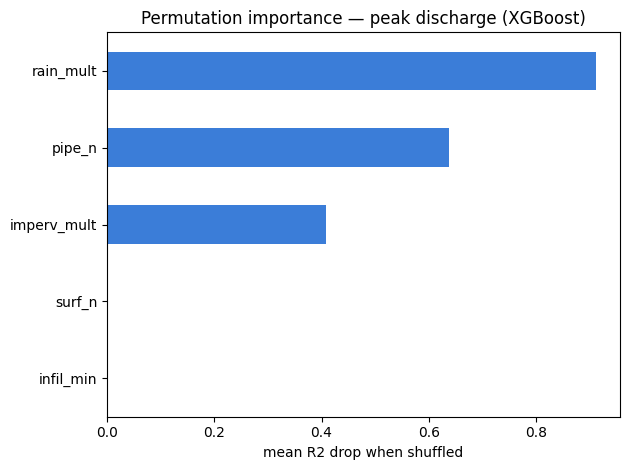

rain_mult      0.911
pipe_n         0.638
imperv_mult    0.409
surf_n         0.001
infil_min      0.000
dtype: float64

In [8]:
from sklearn.inspection import permutation_importance

r = permutation_importance(peak_fitted[best_peak], Xte, actual,
                           n_repeats=20, random_state=SEED)
imp = pd.Series(r.importances_mean, index=FEATURES).sort_values()
imp.plot.barh(color="#3b7dd8")
plt.title(f"Permutation importance — peak discharge ({best_peak})")
plt.xlabel("mean R2 drop when shuffled"); plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).round(3)

## 8. Light hyperparameter tuning (RandomizedSearchCV)

Due-diligence check: does tuning XGBoost beat the defaults? Tuned on the **training set via 5-fold CV only** (test set untouched), 40 random candidates per task. We judge by **CV gain** (the test sets are small, so test deltas can be noise). Peak + classifier are expected near-ceiling; flood volume has the most headroom.

In [9]:
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.base import clone
from scipy.stats import randint, uniform

N_ITER = 40
XGB_SPACE = {
    "n_estimators":     randint(200, 700),
    "max_depth":        randint(2, 7),
    "learning_rate":    uniform(0.01, 0.19),   # 0.01 - 0.20
    "subsample":        uniform(0.6, 0.4),     # 0.6 - 1.0
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 8),
    "reg_lambda":       uniform(0.0, 3.0),
    "reg_alpha":        uniform(0.0, 1.0),
}

def _auc(model, Xv, yv_): return roc_auc_score(yv_, model.predict_proba(Xv)[:, 1])
def _r2(model, Xv, yv_):  return r2_score(yv_, model.predict(Xv))

# task -> default estimator + data + CV scoring + test metric
tune_tasks = [
    ("peak", XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=4,
                          subsample=0.9, random_state=SEED),
     Xtr, y_peak.loc[idx_train], Xte, y_peak.loc[idx_test], "r2", _r2, "R2"),
    ("flood_volume", XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=4,
                                  subsample=0.9, random_state=SEED),
     X.loc[ftr], yv.loc[ftr], X.loc[fte], yv.loc[fte], "r2", _r2, "R2"),
    ("floods?", XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                              subsample=0.9, random_state=SEED, eval_metric="logloss"),
     Xtr, ytr_c, Xte, yte_c, "roc_auc", _auc, "AUC"),
]

rows, tuned_models = [], {}
for name, default, Xt, yt, Xv, yv_, scoring, test_fn, mlabel in tune_tasks:
    search = RandomizedSearchCV(clone(default), XGB_SPACE, n_iter=N_ITER, cv=5,
                                scoring=scoring, random_state=SEED, n_jobs=-1)
    search.fit(Xt, yt)
    default.fit(Xt, yt)
    def_cv = cross_val_score(default, Xt, yt, cv=5, scoring=scoring).mean()
    rows.append({
        "task": name, "metric": mlabel,
        "default_CV": def_cv, "tuned_CV": search.best_score_,
        "default_test": test_fn(default, Xv, yv_),
        "tuned_test": test_fn(search.best_estimator_, Xv, yv_),
    })
    tuned_models[name] = search.best_estimator_

tune_compare = pd.DataFrame(rows)
tune_compare["CV_gain"]   = tune_compare["tuned_CV"]   - tune_compare["default_CV"]
tune_compare["test_gain"] = tune_compare["tuned_test"] - tune_compare["default_test"]

print("Default vs tuned (RandomizedSearchCV, n_iter=40, 5-fold CV):\n")
print(tune_compare.round(4).to_string(index=False))
print("\nVerdict (CV gain > 0.005 = worth keeping):")
for _, r in tune_compare.iterrows():
    print(f"  {r['task']:13s} CV {r['default_CV']:.3f} -> {r['tuned_CV']:.3f} "
          f"(delta {r['CV_gain']:+.3f})  "
          f"{'MEANINGFUL' if r['CV_gain'] > 0.005 else 'negligible'}")

Default vs tuned (RandomizedSearchCV, n_iter=40, 5-fold CV):

        task metric  default_CV  tuned_CV  default_test  tuned_test  CV_gain  test_gain
        peak     R2      0.9691    0.9615        0.9822      0.9745  -0.0075    -0.0077
flood_volume     R2      0.8618    0.8607        0.9156      0.9436  -0.0011     0.0280
     floods?    AUC      0.9907    0.9904        0.9947      0.9943  -0.0003    -0.0004

Verdict (CV gain > 0.005 = worth keeping):
  peak          CV 0.969 -> 0.962 (delta -0.008)  negligible
  flood_volume  CV 0.862 -> 0.861 (delta -0.001)  negligible
  floods?       CV 0.991 -> 0.990 (delta -0.000)  negligible


## 9. Save models + metrics

In [10]:
import joblib

all_metrics = pd.concat([peak_metrics, clf_metrics, vol_metrics], ignore_index=True)
all_metrics.to_csv(PROJECT / "data" / "phase3_metrics.csv", index=False)

joblib.dump(peak_fitted[best_peak], MODELS_DIR / "peak_regressor.joblib")
joblib.dump(clf_fitted[best_clf],   MODELS_DIR / "flood_classifier.joblib")
joblib.dump(vol_fitted[best_vol],   MODELS_DIR / "flood_volume_regressor.joblib")

print("Saved -> data/phase3_metrics.csv and models/*.joblib")
print(f"Best models: peak={best_peak}, floods?={best_clf}, volume={best_vol}")
all_metrics.round(3)

Saved -> data/phase3_metrics.csv and models/*.joblib
Best models: peak=XGBoost, floods?=XGBoost, volume=XGBoost


,task,model,R2,RMSE,MAE,CV_R2,accuracy,precision,recall,F1,ROC_AUC
0,peak_discharge,RandomForest,0.980,0.638,0.431,0.975,NaN,NaN,NaN,NaN,NaN
1,peak_discharge,XGBoost,0.982,0.605,0.446,0.979,NaN,NaN,NaN,NaN,NaN
2,floods?,RandomForest,NaN,NaN,NaN,NaN,0.96,1.0,0.886,0.939,0.996
3,floods?,XGBoost,NaN,NaN,NaN,NaN,0.97,1.0,0.914,0.955,0.995
4,flood_volume,RandomForest,0.861,0.003,0.002,NaN,NaN,NaN,NaN,NaN,NaN
5,flood_volume,XGBoost,0.916,0.002,0.002,NaN,NaN,NaN,NaN,NaN,NaN
